In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import os

from sklearn.datasets import load_wine

# Create folder for saving images
os.makedirs("Output_images", exist_ok=True)

In [18]:
data = load_wine()

X = data.data
y = data.target

df = pd.DataFrame(
    X,
    columns=data.feature_names
)


df["Target"] = y

In [19]:
print("="*60)
print("Dataset Shape")
print("="*60)

print(df.shape)

print()

print("="*60)
print("First Five Rows")
print("="*60)

print(df.head())

print()

print("="*60)
print("Dataset Information")
print("="*60)

print(df.info())

print()

print("="*60)
print("Statistical Summary")
print("="*60)

print(df.describe())

Dataset Shape
(178, 14)

First Five Rows
   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_dil

In [20]:

print(df.duplicated().sum())

0


In [21]:
print(df.isnull().sum())

alcohol                         0
malic_acid                      0
ash                             0
alcalinity_of_ash               0
magnesium                       0
total_phenols                   0
flavanoids                      0
nonflavanoid_phenols            0
proanthocyanins                 0
color_intensity                 0
hue                             0
od280/od315_of_diluted_wines    0
proline                         0
Target                          0
dtype: int64


In [22]:
print(df.dtypes)

alcohol                         float64
malic_acid                      float64
ash                             float64
alcalinity_of_ash               float64
magnesium                       float64
total_phenols                   float64
flavanoids                      float64
nonflavanoid_phenols            float64
proanthocyanins                 float64
color_intensity                 float64
hue                             float64
od280/od315_of_diluted_wines    float64
proline                         float64
Target                            int64
dtype: object


In [23]:
X = df.drop("Target", axis=1)
y = df["Target"]

In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.20,

    random_state=42,

    stratify=y
)

In [25]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(

    random_state=42
)

model.fit(

    X_train,

    y_train
)

,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",42
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples 

In [26]:
y_pred = model.predict(

    X_test
)

In [27]:
from sklearn.metrics import (

    accuracy_score,

    precision_score,

    recall_score,

    f1_score,

    confusion_matrix,

    classification_report
)

accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(
    y_test,
    y_pred,
    average="weighted"
)

recall = recall_score(
    y_test,
    y_pred,
    average="weighted"
)

f1 = f1_score(
    y_test,
    y_pred,
    average="weighted"
)

print("Accuracy :", accuracy)
print("Precision :", precision)
print("Recall :", recall)
print("F1 Score :", f1)

print()

print(classification_report(
    y_test,
    y_pred
))

Accuracy : 0.9444444444444444
Precision : 0.9513888888888888
Recall : 0.9444444444444444
F1 Score : 0.9449614374099499

              precision    recall  f1-score   support

           0       1.00      0.92      0.96        12
           1       0.88      1.00      0.93        14
           2       1.00      0.90      0.95        10

    accuracy                           0.94        36
   macro avg       0.96      0.94      0.95        36
weighted avg       0.95      0.94      0.94        36



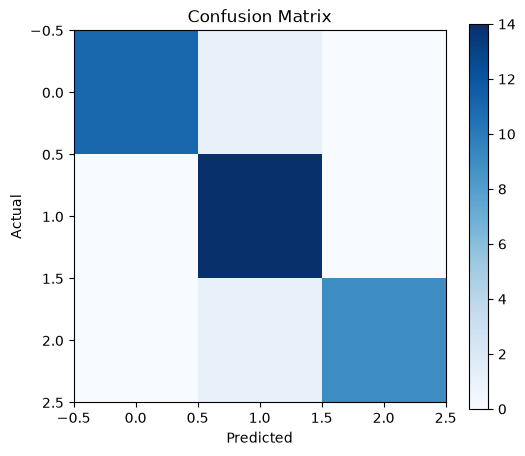

In [28]:
cm = confusion_matrix(
    y_test,
    y_pred
)

plt.figure(figsize=(6,5))

plt.imshow(
    cm,
    cmap="Blues"
)

plt.colorbar()

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.savefig(
    "output_images/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

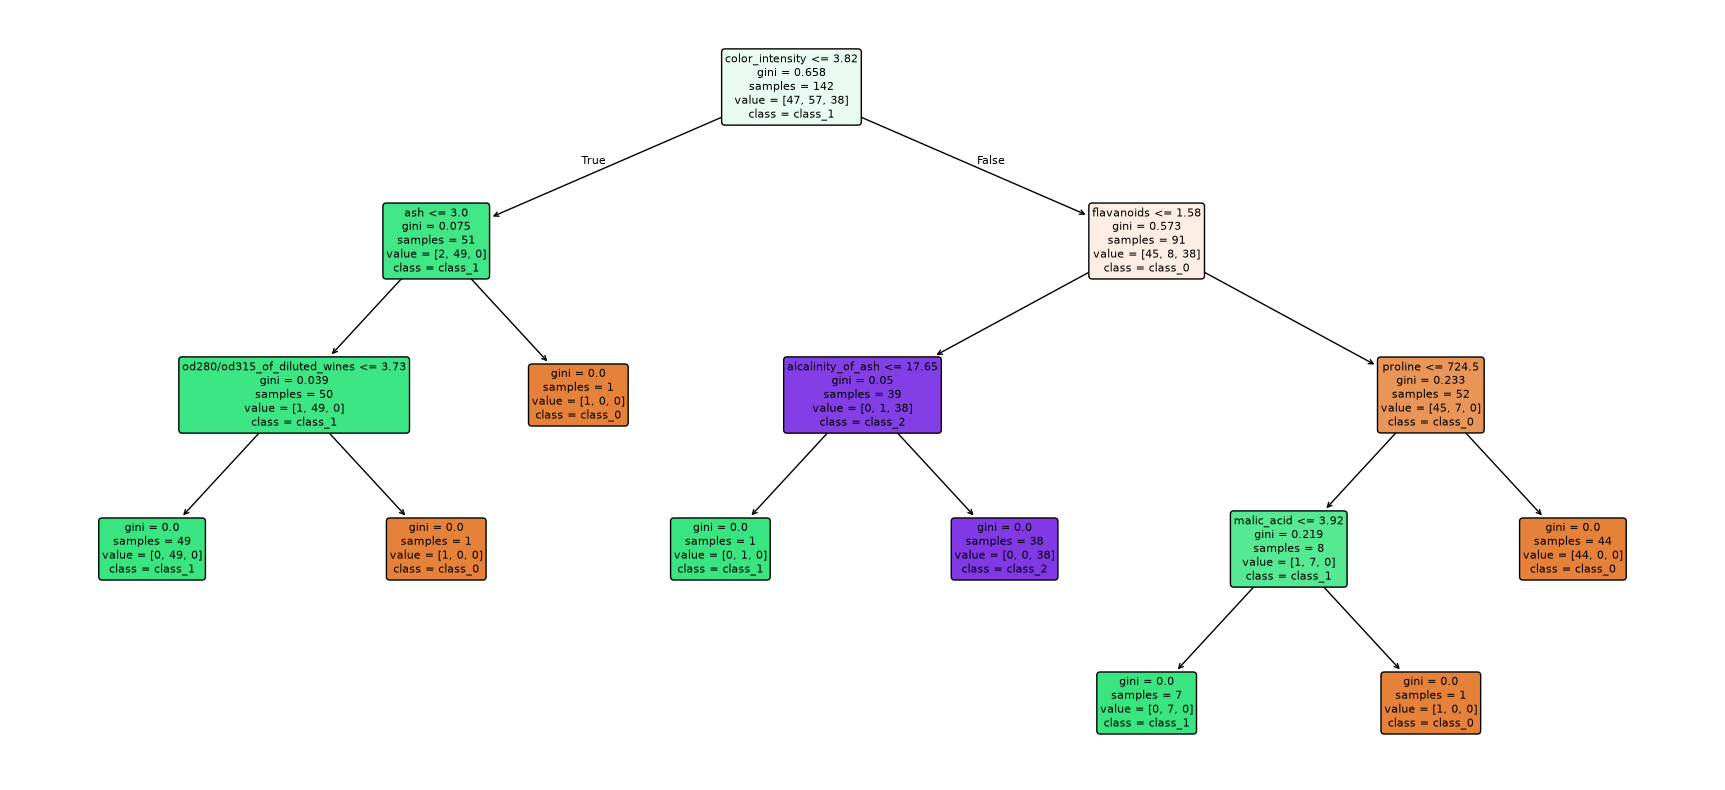

In [29]:
from sklearn.tree import plot_tree

plt.figure(figsize=(22,10))

plot_tree(

    model,

    filled=True,

    feature_names=X.columns,

    class_names=data.target_names,

    rounded=True,

    fontsize=8
)

plt.savefig(
    "output_images/decision_tree.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

                         Feature  Importance
6                     flavanoids    0.408073
9                color_intensity    0.400189
12                       proline    0.110985
11  od280/od315_of_diluted_wines    0.020986
3              alcalinity_of_ash    0.020865
2                            ash    0.020163
1                     malic_acid    0.018738
4                      magnesium    0.000000
0                        alcohol    0.000000
8                proanthocyanins    0.000000
7           nonflavanoid_phenols    0.000000
5                  total_phenols    0.000000
10                           hue    0.000000


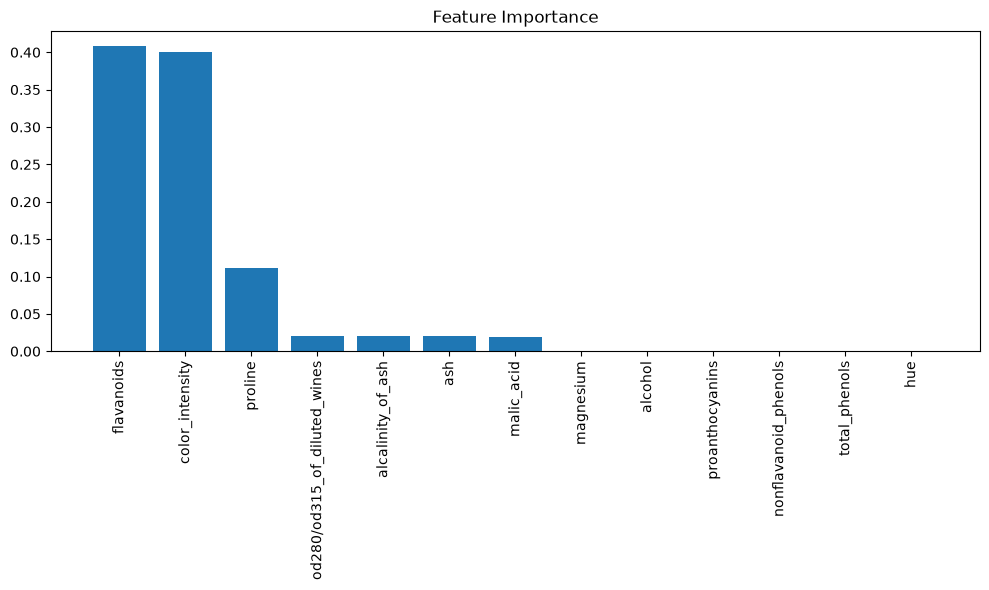

In [30]:
importance = pd.DataFrame({

    "Feature": X.columns,

    "Importance": model.feature_importances_

})

importance = importance.sort_values(

    by="Importance",

    ascending=False
)

print(importance)

plt.figure(figsize=(10,6))

plt.bar(

    importance["Feature"],

    importance["Importance"]
)

plt.xticks(rotation=90)

plt.title("Feature Importance")

plt.tight_layout()

plt.savefig(
    "output_images/feature_importance.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

# GridSearchsCV

In [31]:
from sklearn.model_selection import GridSearchCV

param_grid = {

    "criterion": ["gini", "entropy"],

    "max_depth": [None, 3, 5, 8, 10],

    "min_samples_split": [2, 5, 10],

    "min_samples_leaf": [1, 2, 4]

}

grid = GridSearchCV(

    estimator=DecisionTreeClassifier(
        random_state=42
    ),

    param_grid=param_grid,

    cv=5,

    scoring="accuracy",

    n_jobs=-1
)

grid.fit(
    X_train,
    y_train
)

print("Best Parameters")
print(grid.best_params_)

print()

print("Best CV Score")
print(grid.best_score_)

Best Parameters
{'criterion': 'gini', 'max_depth': 3, 'min_samples_leaf': 2, 'min_samples_split': 2}

Best CV Score
0.930295566502463


In [32]:
best_model = grid.best_estimator_

y_pred_best = best_model.predict(
    X_test
)

print(classification_report(
    y_test,
    y_pred_best
))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        12
           1       1.00      1.00      1.00        14
           2       1.00      1.00      1.00        10

    accuracy                           1.00        36
   macro avg       1.00      1.00      1.00        36
weighted avg       1.00      1.00      1.00        36



In [33]:
df["Wine_Class"] = df["Target"].map({
    0: data.target_names[0],
    1: data.target_names[1],
    2: data.target_names[2]
})

print(df.head())

   alcohol  malic_acid   ash  alcalinity_of_ash  magnesium  total_phenols  \
0    14.23        1.71  2.43               15.6      127.0           2.80   
1    13.20        1.78  2.14               11.2      100.0           2.65   
2    13.16        2.36  2.67               18.6      101.0           2.80   
3    14.37        1.95  2.50               16.8      113.0           3.85   
4    13.24        2.59  2.87               21.0      118.0           2.80   

   flavanoids  nonflavanoid_phenols  proanthocyanins  color_intensity   hue  \
0        3.06                  0.28             2.29             5.64  1.04   
1        2.76                  0.26             1.28             4.38  1.05   
2        3.24                  0.30             2.81             5.68  1.03   
3        3.49                  0.24             2.18             7.80  0.86   
4        2.69                  0.39             1.82             4.32  1.04   

   od280/od315_of_diluted_wines  proline  Target Wine_Class  


In [37]:
import pandas as pd

pd.DataFrame({
    "Class": data.target_names,
    "Target Value": [0, 1, 2]
})

,Class,Target Value
0,class_0,0
1,class_1,1
2,class_2,2


In [35]:
print(data.target_names)

print()

print(df["Target"].value_counts())

['class_0' 'class_1' 'class_2']

Target
1    71
0    59
2    48
Name: count, dtype: int64


In [39]:


print(data.target_names)

['class_0' 'class_1' 'class_2']
